In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd

analysis_file_path = (
    "/content/drive/MyDrive/Dude_Wheres_My_Bike_Project/"
    "01_Data/processed/analysis_ready_v2.csv"
)

df = pd.read_csv(
    analysis_file_path,
    encoding="utf-8-sig",
    dtype={"lor": "string"},
    parse_dates=[
        "record_created_date",
        "offence_start_date",
        "offence_end_date",
        "offence_start",
        "offence_end"
    ]
)

print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()

Rows and columns: (26965, 34)

Column names:
['record_created_date', 'offence_start_date', 'offence_start_hour', 'offence_end_date', 'offence_end_hour', 'lor', 'reported_damage_eur', 'attempt', 'bicycle_type', 'offence_category', 'recording_reason', 'offence_start', 'offence_end', 'offence_window_hours', 'year', 'month_number', 'month_name', 'weekday_number', 'weekday_name', 'is_weekend', 'is_attempt', 'is_attempt_unknown', 'is_zero_damage', 'is_cellar_burglary', 'is_cellar_location', 'is_duplicate_copy', 'is_comparable_ytd', 'district_id', 'district_name', 'forecast_area_id', 'forecast_area_name', 'district_region_id', 'district_region_name', 'planning_area_name']


,record_created_date,offence_start_date,offence_start_hour,offence_end_date,offence_end_hour,lor,reported_damage_eur,attempt,bicycle_type,offence_category,...,is_cellar_location,is_duplicate_copy,is_comparable_ytd,district_id,district_name,forecast_area_id,forecast_area_name,district_region_id,district_region_name,planning_area_name
0,2026-08-08,2026-08-08,0,2026-08-08,0,01200521,0,Ja,Rennrad,Fahrraddiebstahl,...,False,False,True,1,Mitte,120,Moabit,12005,Moabit West,Zwinglistraße
1,2026-08-08,2026-08-01,11,2026-08-01,13,03601347,2150,Nein,Citybike,Fahrraddiebstahl,...,False,False,True,3,Pankow,360,Nördlicher Prenzlauer Berg,36013,Helmholtzplatz,Helmholtzplatz
2,2026-08-08,2026-08-08,0,2026-08-08,0,01200521,0,Ja,Rennrad,Fahrraddiebstahl,...,False,True,True,1,Mitte,120,Moabit,12005,Moabit West,Zwinglistraße
3,2026-08-08,2026-08-05,11,2026-08-05,17,03701554,2650,Nein,Herrenfahrrad,Fahrraddiebstahl,...,False,False,True,3,Pankow,370,Südlicher Prenzlauer Berg,37015,Prenzlauer Berg Südwest,Teutoburger Platz
4,2026-08-08,2026-08-08,12,2026-08-08,17,11401034,1499,Nein,Rennrad,Fahrraddiebstahl,...,False,False,True,11,Lichtenberg,1140,Lichtenberg Mitte,114010,Friedrichsfelde Nord,Tierpark


In [3]:
# identifying the seven geographic columns Person 2 added
print("Geographic columns added by Person 2:")

for column in df.columns[-7:]:
    print(column)

Geographic columns added by Person 2:
district_id
district_name
forecast_area_id
forecast_area_name
district_region_id
district_region_name
planning_area_name


In [4]:
geo_columns = [
    "district_id",
    "district_name",
    "forecast_area_id",
    "forecast_area_name",
    "district_region_id",
    "district_region_name",
    "planning_area_name"
]

print("Missing geographic values:")
print(df[geo_columns].isna().sum())

print("\nUnique geographic areas:")
print("Districts:", df["district_id"].nunique())
print("Forecast areas:", df["forecast_area_id"].nunique())
print("District regions:", df["district_region_id"].nunique())
print("Planning areas:", df["lor"].nunique())

# Check that one LOR code does not have conflicting geographic names
mapping_check = df.groupby("lor")[geo_columns].nunique(dropna=False)
conflicting_lor_codes = (mapping_check > 1).any(axis=1).sum()

print("\nLOR codes with conflicting mappings:", conflicting_lor_codes)
print("Rows preserved:", len(df) == 26965)

Missing geographic values:
district_id             0
district_name           0
forecast_area_id        0
forecast_area_name      0
district_region_id      0
district_region_name    0
planning_area_name      0
dtype: int64

Unique geographic areas:
Districts: 12
Forecast areas: 58
District regions: 143
Planning areas: 534

LOR codes with conflicting mappings: 0
Rows preserved: True


### Geographic join validation

The canonical `analysis_ready_v2.csv` contains 26,965 records and 34 columns.

Independent validation confirmed:

- All records have matching geographic information.
- No rows were added or removed during the join.
- No LOR code maps to conflicting geographic names.
- The reports cover 12 districts, 58 forecast areas, 143 district regions and 534 LOR planning areas.
- Eight of Berlin’s 542 planning areas have no recorded reports in this dataset.

The geographic handoff is accepted. This file will be used as the canonical source for all subsequent analysis.

In [5]:
# the time analysis with monthly report counts:
# Creating a sortable year-month field
df["year_month"] = (
    df["offence_start_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_counts = (
    df.groupby("year_month")
    .size()
    .reset_index(name="reported_incidents")
    .sort_values("year_month")
)

display(monthly_counts)

print("Total reports:", monthly_counts["reported_incidents"].sum())

,year_month,reported_incidents
0,2025-01,1155
1,2025-02,947
2,2025-03,1547
3,2025-04,1603
4,2025-05,1948
5,2025-06,1868
6,2025-07,1797
7,2025-08,1353
8,2025-09,1545
9,2025-10,1346


Total reports: 26965


In [6]:
# Now calculating the fair year-to-date comparison
comparable_data = df[df["is_comparable_ytd"]].copy()

ytd_counts = (
    comparable_data.groupby("year")
    .size()
    .reset_index(name="reported_incidents")
)

count_2025 = ytd_counts.loc[
    ytd_counts["year"] == 2025,
    "reported_incidents"
].iloc[0]

count_2026 = ytd_counts.loc[
    ytd_counts["year"] == 2026,
    "reported_incidents"
].iloc[0]

difference = count_2026 - count_2025
percentage_change = difference / count_2025 * 100

display(ytd_counts)

print("Difference:", difference)
print("Percentage change:", round(percentage_change, 1), "%")

,year,reported_incidents
0,2025,11185
1,2026,9629


Difference: -1556
Percentage change: -13.9 %


year,month_number,month_name,2025,2026
0,1,January,1155,646
1,2,February,947,794
2,3,March,1547,1330
3,4,April,1603,1480
4,5,May,1948,1628
5,6,June,1868,1833
6,7,July,1797,1658
7,8,August,320,260


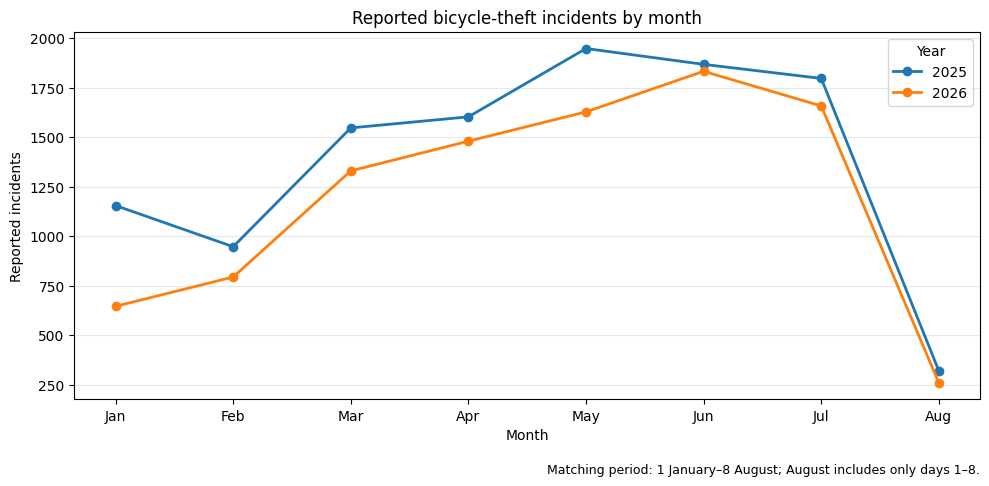

In [7]:
# Now comparing the two years month by month using only the matching period. A line chart is appropriate because the months are ordered over time

import matplotlib.pyplot as plt

monthly_comparison = (
    comparable_data
    .groupby(["month_number", "month_name", "year"])
    .size()
    .reset_index(name="reported_incidents")
)

monthly_wide = (
    monthly_comparison
    .pivot(
        index=["month_number", "month_name"],
        columns="year",
        values="reported_incidents"
    )
    .reset_index()
    .sort_values("month_number")
)

display(monthly_wide)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_wide["month_number"],
    monthly_wide[2025],
    marker="o",
    linewidth=2,
    label="2025"
)

ax.plot(
    monthly_wide["month_number"],
    monthly_wide[2026],
    marker="o",
    linewidth=2,
    label="2026"
)

ax.set_title("Reported bicycle-theft incidents by month")
ax.set_xlabel("Month")
ax.set_ylabel("Reported incidents")

ax.set_xticks(
    monthly_wide["month_number"],
    monthly_wide["month_name"].str[:3]
)

ax.legend(title="Year")
ax.grid(axis="y", alpha=0.3)

ax.text(
    1,
    -0.20,
    "Matching period: 1 January–8 August; August includes only days 1–8.",
    transform=ax.transAxes,
    ha="right",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Monthly comparison findings

For the matching period, reported incidents were 13.9% lower in 2026 than in 2025.

Both years show an increase from late winter toward spring and early summer. Report counts in 2026 were below the corresponding 2025 count in every comparable month, although the difference was very small in June.

August includes only 1–8 August in both years. Therefore, its sharp visual decline must not be interpreted as a normal monthly decrease.

These results describe changes in police-recorded reports. They do not measure the individual risk of bicycle theft.

In [8]:
# Now comparing weekdays fairly. We calculate the average number of reports per calendar day, because the dataset may contain different numbers of Mondays, Tuesdays, etc.
# Count reports for every calendar date
daily_counts = (
    df.groupby("offence_start_date")
    .size()
    .rename("reported_incidents")
)

# Include every date in the dataset period, even if it has zero reports
complete_date_range = pd.date_range(
    df["offence_start_date"].min(),
    df["offence_start_date"].max(),
    freq="D"
)

daily_data = (
    daily_counts
    .reindex(complete_date_range, fill_value=0)
    .rename_axis("date")
    .reset_index()
)

daily_data["weekday_name"] = daily_data["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_summary = (
    daily_data.groupby("weekday_name")
    .agg(
        calendar_days=("date", "count"),
        total_reports=("reported_incidents", "sum"),
        average_reports_per_day=("reported_incidents", "mean")
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_summary["share_of_reports_pct"] = (
    weekday_summary["total_reports"]
    / weekday_summary["total_reports"].sum()
    * 100
)

weekday_summary["average_reports_per_day"] = (
    weekday_summary["average_reports_per_day"].round(1)
)

weekday_summary["share_of_reports_pct"] = (
    weekday_summary["share_of_reports_pct"].round(1)
)

display(weekday_summary)

,weekday_name,calendar_days,total_reports,average_reports_per_day,share_of_reports_pct
0,Monday,83,4018,48.4,14.9
1,Tuesday,83,4041,48.7,15.0
2,Wednesday,84,4113,49.0,15.3
3,Thursday,84,4020,47.9,14.9
4,Friday,84,4211,50.1,15.6
5,Saturday,84,3611,43.0,13.4
6,Sunday,83,2951,35.6,10.9


In [9]:
# Now calculating the overall weekday-versus-weekend difference

daily_data["day_type"] = daily_data["date"].dt.dayofweek.map(
    lambda day: "Weekend" if day >= 5 else "Weekday"
)

day_type_summary = (
    daily_data.groupby("day_type")
    .agg(
        calendar_days=("date", "count"),
        total_reports=("reported_incidents", "sum"),
        average_reports_per_day=("reported_incidents", "mean")
    )
    .reset_index()
)

day_type_summary["average_reports_per_day"] = (
    day_type_summary["average_reports_per_day"].round(1)
)

weekday_average = day_type_summary.loc[
    day_type_summary["day_type"] == "Weekday",
    "average_reports_per_day"
].iloc[0]

weekend_average = day_type_summary.loc[
    day_type_summary["day_type"] == "Weekend",
    "average_reports_per_day"
].iloc[0]

weekend_difference_pct = (
    (weekend_average - weekday_average)
    / weekday_average
    * 100
)

display(day_type_summary)

print(
    "Weekend difference compared with weekdays:",
    round(weekend_difference_pct, 1),
    "%"
)


,day_type,calendar_days,total_reports,average_reports_per_day
0,Weekday,418,20403,48.8
1,Weekend,167,6562,39.3


Weekend difference compared with weekdays: -19.5 %


### Weekday and weekend findings

Friday had the highest average number of reports, with 50.1 reports per calendar day. Sunday had the lowest average, with 35.6 reports per day.

Across the full dataset period:

- Weekdays averaged 48.8 reports per day.
- Weekends averaged 39.3 reports per day.
- The weekend average was approximately 19.5% lower than the weekday average.

These results are based on the reported offence-start date. Because many records describe a possible time window rather than an exact incident time, the weekday may not always represent the precise day on which the bicycle was stolen.

In [10]:
# Now classifying how precise each reported offence window is
import numpy as np

df["time_window_group"] = pd.cut(
    df["offence_window_hours"],
    bins=[-0.001, 0, 3, 12, 24, np.inf],
    labels=[
        "Exact/zero-hour window",
        "Narrow: 1–3 hours",
        "Medium: 4–12 hours",
        "Broad: 13–24 hours",
        "Very broad: over 24 hours"
    ]
)

time_window_summary = (
    df["time_window_group"]
    .value_counts(sort=False)
    .rename_axis("time_window_group")
    .reset_index(name="reported_incidents")
)

time_window_summary["share_pct"] = (
    time_window_summary["reported_incidents"]
    / len(df)
    * 100
).round(1)

display(time_window_summary)

,time_window_group,reported_incidents,share_pct
0,Exact/zero-hour window,3075,11.4
1,Narrow: 1–3 hours,5327,19.8
2,Medium: 4–12 hours,8275,30.7
3,Broad: 13–24 hours,5959,22.1
4,Very broad: over 24 hours,4329,16.1


In [11]:
hour_data = df[df["offence_window_hours"] <= 3].copy()

hour_data["approx_incident_time"] = (
    hour_data["offence_start"]
    + pd.to_timedelta(
        hour_data["offence_window_hours"] / 2,
        unit="h"
    )
)

hour_data["approx_hour"] = hour_data["approx_incident_time"].dt.hour

hour_data["time_period"] = pd.cut(
    hour_data["approx_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=[
        "Night (00–05)",
        "Morning (06–11)",
        "Afternoon (12–17)",
        "Evening (18–23)"
    ]
)

time_period_summary = (
    hour_data["time_period"]
    .value_counts(sort=False)
    .rename_axis("time_period")
    .reset_index(name="reported_incidents")
)

time_period_summary["share_pct"] = (
    time_period_summary["reported_incidents"]
    / len(hour_data)
    * 100
).round(1)

display(time_period_summary)

print("Records used:", len(hour_data))
print(
    "Share of complete dataset:",
    round(len(hour_data) / len(df) * 100, 1),
    "%"
)

,time_period,reported_incidents,share_pct
0,Night (00–05),510,6.1
1,Morning (06–11),1433,17.1
2,Afternoon (12–17),3396,40.4
3,Evening (18–23),3063,36.5


Records used: 8402
Share of complete dataset: 31.2 %


### Approximate time-of-day findings

Only records with an offence window of three hours or less were used for the time-of-day analysis. This produced a subset of 8,402 reports, representing 31.2% of the complete dataset.

The midpoint of each short offence window was used as an approximate incident time.

- Afternoon accounted for 40.4% of the selected reports.
- Evening accounted for 36.5%.
- Together, afternoon and evening represented 76.9% of the short-window reports.
- Night represented only 6.1%.

This does not establish the exact time when bicycles are most often stolen. Short-window incidents may differ systematically from incidents with broad or uncertain time windows. Therefore, the result applies only to this selected subset.

,approx_hour,reported_incidents,share_pct
0,0,146,1.7
1,1,94,1.1
2,2,91,1.1
3,3,68,0.8
4,4,64,0.8
5,5,47,0.6
6,6,74,0.9
7,7,132,1.6
8,8,187,2.2
9,9,267,3.2


Five highest approximate hours:


,approx_hour,reported_incidents,share_pct
19,19,775,9.2
17,17,731,8.7
18,18,726,8.6
16,16,712,8.5
20,20,631,7.5


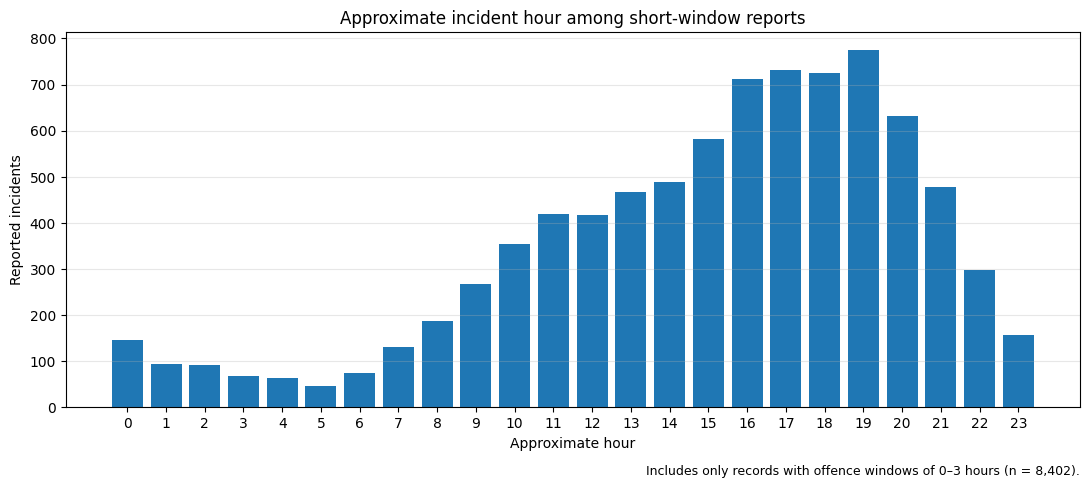

In [12]:
# Now calculating the approximate hourly distribution for the same 8,402 short-window records
hourly_summary = (
    hour_data.groupby("approx_hour")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("reported_incidents")
    .reset_index()
)

hourly_summary["share_pct"] = (
    hourly_summary["reported_incidents"]
    / len(hour_data)
    * 100
).round(1)

display(hourly_summary)

print("Five highest approximate hours:")
display(
    hourly_summary.nlargest(
        5,
        "reported_incidents"
    )
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    hourly_summary["approx_hour"],
    hourly_summary["reported_incidents"]
)

ax.set_title(
    "Approximate incident hour among short-window reports"
)
ax.set_xlabel("Approximate hour")
ax.set_ylabel("Reported incidents")
ax.set_xticks(range(24))
ax.grid(axis="y", alpha=0.3)

ax.text(
    1,
    -0.18,
    "Includes only records with offence windows of 0–3 hours (n = 8,402).",
    transform=ax.transAxes,
    ha="right",
    fontsize=9
)

plt.tight_layout()
plt.show()

In [13]:
exact_hour_data = df[
    df["offence_window_hours"] == 0
].copy()

exact_hour_summary = (
    exact_hour_data.groupby("offence_start_hour")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("reported_incidents")
    .reset_index()
)

exact_hour_summary["share_pct"] = (
    exact_hour_summary["reported_incidents"]
    / len(exact_hour_data)
    * 100
).round(1)

print("Zero-hour records used:", len(exact_hour_data))
print("\nFive highest hours among zero-hour records:")

display(
    exact_hour_summary.nlargest(
        5,
        "reported_incidents"
    )
)

Zero-hour records used: 3075

Five highest hours among zero-hour records:


,offence_start_hour,reported_incidents,share_pct
16,16,229,7.4
18,18,221,7.2
17,17,218,7.1
15,15,201,6.5
19,19,200,6.5


### Hourly sensitivity check

The short-window midpoint analysis and the zero-hour-only analysis produced different single peak hours:

- The midpoint analysis peaked at approximately 19:00.
- The zero-hour-only analysis peaked at 16:00.

However, both methods consistently concentrated their highest report counts between approximately 15:00 and 20:00.

Therefore, the analysis supports a broader late-afternoon and early-evening concentration. It does not support claiming that one exact hour is Berlin’s “most dangerous hour.”

The hourly result is affected by uncertainty in the reported offence windows and by the selection of records with relatively precise times.

In [14]:
# we begin the bicycle-type analysis using only completed/non-attempted incidents. This keeps the 154 attempted incidents separate.
bike_type_translation = {
    "Herrenfahrrad": "Men's bicycle",
    "Damenfahrrad": "Women's bicycle",
    "Fahrrad": "Bicycle (unspecified)",
    "Mountainbike": "Mountain bike",
    "Kinderfahrrad": "Children's bicycle",
    "Rennrad": "Road bicycle",
    "diverse Fahrräder": "Various bicycles",
    "Trekkingrad": "Trekking bicycle",
    "Citybike": "City bicycle",
    "Lastenfahrrad": "Cargo bicycle",
    "Hollandrad": "Dutch-style bicycle",
    "Klapprad": "Folding bicycle",
    "BMX": "BMX"
}

bike_data = df[df["attempt"] == "Nein"].copy()

bike_data["bicycle_type_en"] = (
    bike_data["bicycle_type"]
    .map(bike_type_translation)
)

print(
    "Untranslated bicycle types:",
    bike_data["bicycle_type_en"].isna().sum()
)

bike_type_summary = (
    bike_data["bicycle_type_en"]
    .value_counts()
    .rename_axis("bicycle_type")
    .reset_index(name="reported_incidents")
)

bike_type_summary["share_pct"] = (
    bike_type_summary["reported_incidents"]
    / len(bike_data)
    * 100
).round(1)

display(bike_type_summary)

print("Completed incidents analyzed:", len(bike_data))

Untranslated bicycle types: 0


,bicycle_type,reported_incidents,share_pct
0,Men's bicycle,10877,40.6
1,Women's bicycle,5902,22.0
2,Bicycle (unspecified),4676,17.4
3,Mountain bike,1308,4.9
4,Children's bicycle,1201,4.5
5,Road bicycle,909,3.4
6,Various bicycles,651,2.4
7,Trekking bicycle,514,1.9
8,City bicycle,503,1.9
9,Cargo bicycle,133,0.5


Completed incidents analyzed: 26804


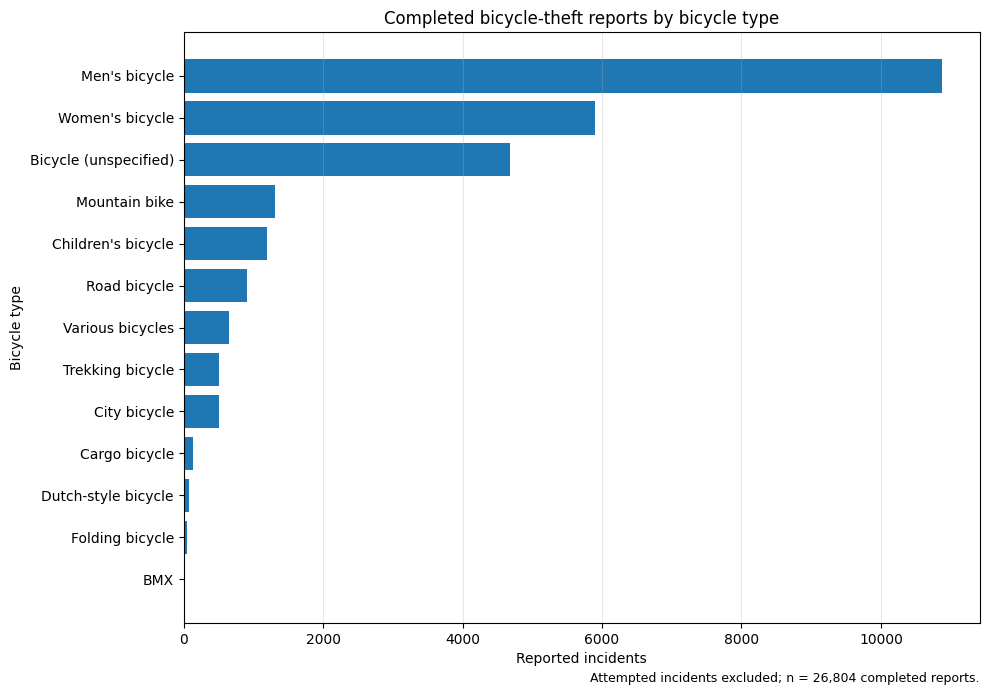

In [15]:
# Now creating a horizontal bar chart
bike_chart_data = bike_type_summary.sort_values(
    "reported_incidents",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    bike_chart_data["bicycle_type"],
    bike_chart_data["reported_incidents"]
)

ax.set_title(
    "Completed bicycle-theft reports by bicycle type"
)
ax.set_xlabel("Reported incidents")
ax.set_ylabel("Bicycle type")
ax.grid(axis="x", alpha=0.3)

ax.text(
    1,
    -0.10,
    "Attempted incidents excluded; n = 26,804 completed reports.",
    transform=ax.transAxes,
    ha="right",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Bicycle-type findings

The bicycle-type analysis excluded attempted incidents and used 26,804 completed reports.

- Men’s bicycles were the largest recorded category, with 10,877 reports (40.6%).
- Women’s bicycles accounted for 5,902 reports (22.0%).
- Unspecified bicycles accounted for 4,676 reports (17.4%).
- Together, these three categories represented 80.0% of completed reports.

These values describe the composition of police-recorded cases. They do not show that one bicycle type has a higher individual theft risk, because the dataset does not contain the number of bicycles of each type owned, used or parked in Berlin.

In [16]:
# Next, we’ll check whether the bicycle-type composition changes meaningfully between months.
# examining whether the five most common bicycle types change much between months. We’ll exclude August 2026 because it contains only eight days.

top_five_types = bike_type_summary.head(5)["bicycle_type"].tolist()

# Exclude incomplete August 2026
monthly_bike_data = bike_data[
    bike_data["year_month"] != "2026-08"
].copy()

monthly_type_counts = (
    monthly_bike_data
    .groupby(["year_month", "bicycle_type_en"])
    .size()
    .reset_index(name="reported_incidents")
)

monthly_totals = (
    monthly_bike_data
    .groupby("year_month")
    .size()
    .reset_index(name="monthly_total")
)

monthly_type_counts = monthly_type_counts.merge(
    monthly_totals,
    on="year_month",
    how="left"
)

monthly_type_counts["monthly_share_pct"] = (
    monthly_type_counts["reported_incidents"]
    / monthly_type_counts["monthly_total"]
    * 100
)

top_monthly_types = monthly_type_counts[
    monthly_type_counts["bicycle_type_en"].isin(top_five_types)
].copy()

type_share_variation = (
    top_monthly_types
    .groupby("bicycle_type_en")
    .agg(
        minimum_monthly_share=("monthly_share_pct", "min"),
        average_monthly_share=("monthly_share_pct", "mean"),
        maximum_monthly_share=("monthly_share_pct", "max")
    )
    .reset_index()
)

type_share_variation["share_range"] = (
    type_share_variation["maximum_monthly_share"]
    - type_share_variation["minimum_monthly_share"]
)

numeric_columns = [
    "minimum_monthly_share",
    "average_monthly_share",
    "maximum_monthly_share",
    "share_range"
]

type_share_variation[numeric_columns] = (
    type_share_variation[numeric_columns].round(1)
)

type_share_variation = type_share_variation.sort_values(
    "average_monthly_share",
    ascending=False
)

display(type_share_variation)

,bicycle_type_en,minimum_monthly_share,average_monthly_share,maximum_monthly_share,share_range
2,Men's bicycle,18.9,41.7,47.5,28.6
4,Women's bicycle,9.4,22.2,25.7,16.3
0,Bicycle (unspecified),6.8,17.9,20.9,14.0
3,Mountain bike,2.0,4.5,13.8,11.8
1,Children's bicycle,1.9,4.4,6.5,4.6


This result reveals a potential data-quality issue: the very large monthly ranges may reflect a change in bicycle classification, not a real change in which bicycles were stolen.

For example, men’s bicycles fall to 18.9% in one month, while mountain bikes rise to 13.8%. Let’s inspect the recent months.

In [17]:
recent_type_counts = (
    monthly_type_counts[
        monthly_type_counts["year_month"].between(
            "2026-03", "2026-07"
        )
    ]
    .pivot(
        index="year_month",
        columns="bicycle_type_en",
        values="reported_incidents"
    )
    .fillna(0)
    .astype(int)
)

display(recent_type_counts)

bicycle_type_en,BMX,Bicycle (unspecified),Cargo bicycle,Children's bicycle,City bicycle,Dutch-style bicycle,Folding bicycle,Men's bicycle,Mountain bike,Road bicycle,Trekking bicycle,Various bicycles,Women's bicycle
year_month,,,,,,,,,,,,,
2026-03,0,247,6,76,2,0,0,551,54,31,1,27,326
2026-04,0,262,5,56,4,1,0,646,60,45,2,42,352
2026-05,0,304,16,72,10,2,2,720,51,47,14,21,353
2026-06,1,143,19,118,217,32,17,432,211,166,209,36,219
2026-07,2,112,21,63,238,31,24,310,227,173,248,37,154


### Bicycle-type classification limitation

The monthly analysis indicates a likely change in bicycle-type classification or recording practice around June 2026.

Several detailed categories increased suddenly between May and June 2026:

- City bicycles: 10 to 217 reports
- Trekking bicycles: 14 to 209
- Mountain bikes: 51 to 211
- Road bicycles: 47 to 166

At the same time, the broader men’s, women’s and unspecified bicycle categories decreased substantially.

This pattern should not be interpreted as a sudden real-world change in which bicycles were stolen. Bicycle-type categories do not appear to be fully comparable across the entire dataset period.

Overall bicycle-type counts can still describe the labels recorded in the complete dataset, but temporal comparisons by bicycle type should either be separated into periods before and after June 2026 or omitted from the final conclusions.

That completes the responsible bicycle-type analysis. Next is  overall financial analysis.

In [18]:
# creating the correct financial-analysis samples and comparing results with and without €0 values.
# Completed incidents only; exclude cellar-burglary records
financial_data = df[
    (df["attempt"] == "Nein")
    & (~df["is_cellar_burglary"])
].copy()

# Positive reported damage for bicycle-value summaries
positive_financial_data = financial_data[
    financial_data["reported_damage_eur"] > 0
].copy()

print("Completed non-cellar records:", len(financial_data))
print(
    "€0 records:",
    (financial_data["reported_damage_eur"] == 0).sum()
)
print(
    "Positive-value records:",
    len(positive_financial_data)
)

financial_summary = pd.DataFrame({
    "Including €0 values":
        financial_data["reported_damage_eur"].describe(
            percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
        ),
    "Positive values only":
        positive_financial_data["reported_damage_eur"].describe(
            percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
        )
})

display(financial_summary.round(1))

Completed non-cellar records: 25457
€0 records: 71
Positive-value records: 25386


,Including €0 values,Positive values only
count,25457.0,25386.0
mean,1254.1,1257.7
std,1168.9,1168.6
min,0.0,1.0
25%,500.0,500.0
50%,899.0,899.0
75%,1600.0,1600.0
90%,2725.0,2734.5
95%,3599.0,3599.8
99%,5640.9,5643.2


Total reported damage: €31,926,749
Mean positive reported damage: €1,257.7
Median positive reported damage: €899.0


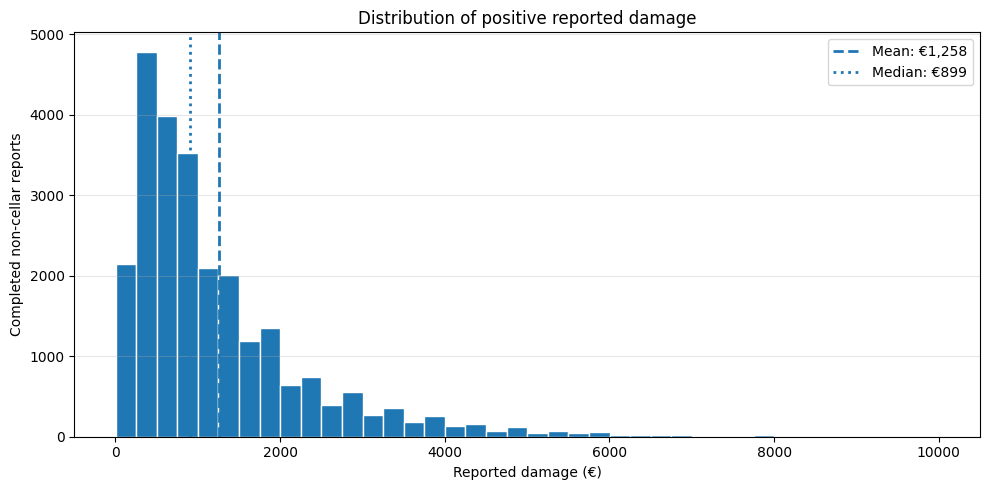

In [19]:
# calculating the total and visualize the distribution
total_reported_damage = (
    financial_data["reported_damage_eur"].sum()
)

mean_positive_damage = (
    positive_financial_data["reported_damage_eur"].mean()
)

median_positive_damage = (
    positive_financial_data["reported_damage_eur"].median()
)

print(
    "Total reported damage:",
    f"€{total_reported_damage:,.0f}"
)
print(
    "Mean positive reported damage:",
    f"€{mean_positive_damage:,.1f}"
)
print(
    "Median positive reported damage:",
    f"€{median_positive_damage:,.1f}"
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    positive_financial_data["reported_damage_eur"],
    bins=40,
    edgecolor="white"
)

ax.axvline(
    mean_positive_damage,
    linestyle="--",
    linewidth=2,
    label=f"Mean: €{mean_positive_damage:,.0f}"
)

ax.axvline(
    median_positive_damage,
    linestyle=":",
    linewidth=2,
    label=f"Median: €{median_positive_damage:,.0f}"
)

ax.set_title(
    "Distribution of positive reported damage"
)
ax.set_xlabel("Reported damage (€)")
ax.set_ylabel("Completed non-cellar reports")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Now comparing positive reported damage by bicycle type. The ranking will require at least 20 records so a category such as BMX is not ranked from only a few cases.
positive_financial_data["bicycle_type_en"] = (
    positive_financial_data["bicycle_type"]
    .map(bike_type_translation)
)

financial_by_type = (
    positive_financial_data
    .groupby("bicycle_type_en")
    .agg(
        reports=("reported_damage_eur", "size"),
        median_damage_eur=("reported_damage_eur", "median"),
        mean_damage_eur=("reported_damage_eur", "mean"),
        total_damage_eur=("reported_damage_eur", "sum")
    )
    .reset_index()
)

# Require at least 20 positive-value reports
financial_by_type_reliable = (
    financial_by_type[
        financial_by_type["reports"] >= 20
    ]
    .sort_values(
        "median_damage_eur",
        ascending=False
    )
    .copy()
)

money_columns = [
    "median_damage_eur",
    "mean_damage_eur",
    "total_damage_eur"
]

financial_by_type_reliable[money_columns] = (
    financial_by_type_reliable[money_columns].round(1)
)

display(financial_by_type_reliable)

,bicycle_type_en,reports,median_damage_eur,mean_damage_eur,total_damage_eur
2,Cargo bicycle,127,3000.0,3445.6,437597
9,Road bicycle,775,1273.0,1471.5,1140425
11,Various bicycles,467,1200.0,2031.0,948479
1,Bicycle (unspecified),4467,1049.0,1416.9,6329253
7,Men's bicycle,10443,1000.0,1341.0,14004284
4,City bicycle,476,949.5,1312.5,624756
10,Trekking bicycle,490,940.0,1265.1,619881
12,Women's bicycle,5709,728.0,1047.1,5978169
6,Folding bicycle,50,649.5,962.3,48114
8,Mountain bike,1143,625.0,1053.0,1203596


The main findings are:

Cargo bicycles have the highest median reported damage: €3,000 from 127 records.
Road bicycles are second: €1,273.
Men’s bicycles produce the largest total reported damage—about €14.0 million—mainly because they appear much more frequently.
Children’s bicycles have the lowest median: €449

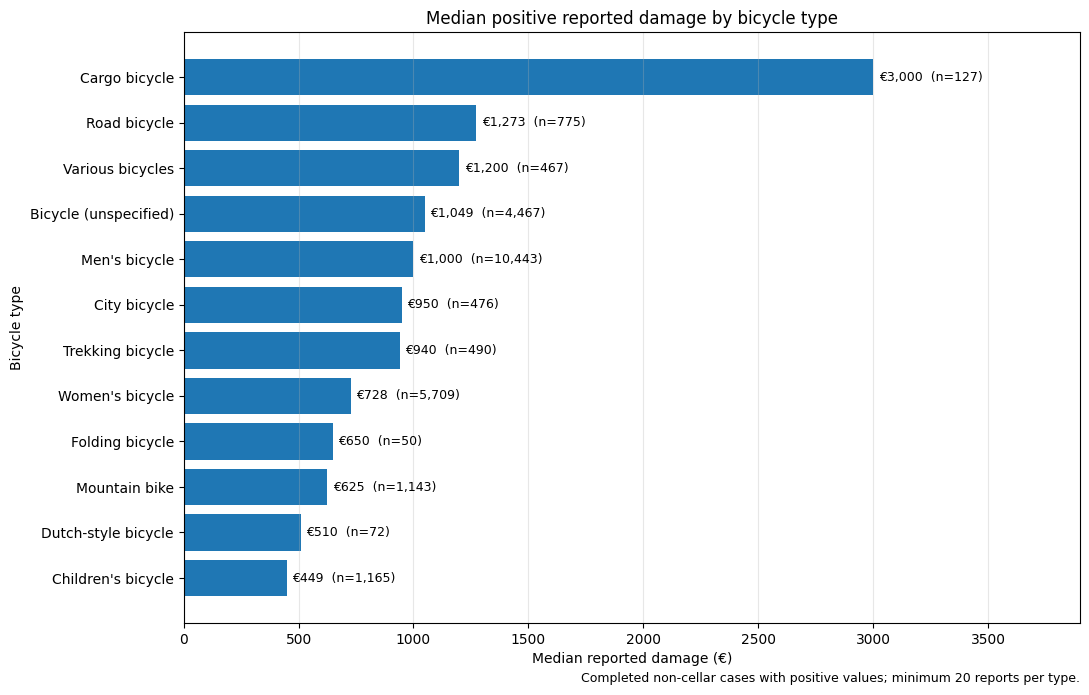

In [21]:
# Creating a median-value chart:
type_value_chart = financial_by_type_reliable.sort_values(
    "median_damage_eur",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    type_value_chart["bicycle_type_en"],
    type_value_chart["median_damage_eur"]
)

labels = [
    f"€{value:,.0f}  (n={count:,})"
    for value, count in zip(
        type_value_chart["median_damage_eur"],
        type_value_chart["reports"]
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4,
    fontsize=9
)

ax.set_xlim(
    0,
    type_value_chart["median_damage_eur"].max() * 1.30
)

ax.set_title(
    "Median positive reported damage by bicycle type"
)
ax.set_xlabel("Median reported damage (€)")
ax.set_ylabel("Bicycle type")
ax.grid(axis="x", alpha=0.3)

ax.text(
    1,
    -0.10,
    "Completed non-cellar cases with positive values; minimum 20 reports per type.",
    transform=ax.transAxes,
    ha="right",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Financial findings

The bicycle-only financial analysis used completed, non-cellar incidents. Cellar-burglary cases were excluded because their recorded damage may include objects other than bicycles.

There were 25,457 eligible records:

- 71 records had a reported value of €0 and were retained but treated separately.
- 25,386 records had a positive reported value.

For positive-value records:

- Total reported damage was €31,926,749.
- Mean reported damage was €1,257.70.
- Median reported damage was €899.
- The mean was higher than the median, showing a right-skewed distribution with a smaller number of high-value cases.

By bicycle type:

- Cargo bicycles had the highest median reported damage: €3,000 (127 reports).
- Road bicycles had a median of €1,273 (775 reports).
- Men’s bicycles produced the largest combined reported damage: approximately €14.0 million, primarily because they were the most frequently recorded category.
- Children’s bicycles had the lowest median among categories meeting the minimum sample-size requirement: €449.

These figures represent police-recorded financial damage. They are not verified retail prices and do not estimate losses from incidents that were never reported. Bicycle-type comparisons must also be interpreted carefully because the category structure appears to change around June 2026.

In [22]:
# Exporting the results as one Excel workbook with separate sheets.
import os

exports_folder = (
    "/content/drive/MyDrive/Dude_Wheres_My_Bike_Project/"
    "06_Exports"
)

summary_file_path = (
    exports_folder
    + "/P1_analysis_summary_tables_v1.xlsx"
)

os.makedirs(exports_folder, exist_ok=True)

if os.path.exists(summary_file_path):
    print("File already exists. Nothing was overwritten:")
    print(summary_file_path)

else:
    with pd.ExcelWriter(
        summary_file_path,
        engine="openpyxl"
    ) as writer:

        monthly_counts.to_excel(
            writer,
            sheet_name="Monthly counts",
            index=False
        )

        ytd_counts.to_excel(
            writer,
            sheet_name="YTD comparison",
            index=False
        )

        weekday_summary.to_excel(
            writer,
            sheet_name="Weekday summary",
            index=False
        )

        day_type_summary.to_excel(
            writer,
            sheet_name="Weekday weekend",
            index=False
        )

        time_window_summary.to_excel(
            writer,
            sheet_name="Time reliability",
            index=False
        )

        time_period_summary.to_excel(
            writer,
            sheet_name="Time periods",
            index=False
        )

        hourly_summary.to_excel(
            writer,
            sheet_name="Hourly short windows",
            index=False
        )

        bike_type_summary.to_excel(
            writer,
            sheet_name="Bicycle types",
            index=False
        )

        financial_by_type_reliable.to_excel(
            writer,
            sheet_name="Financial by type",
            index=False
        )

    os.sync()

    print("Summary workbook created:")
    print(summary_file_path)

File already exists. Nothing was overwritten:
/content/drive/MyDrive/Dude_Wheres_My_Bike_Project/06_Exports/P1_analysis_summary_tables_v1.xlsx


In [23]:
# verifying that the workbook opens and contains all nine sheets.
workbook_check = pd.ExcelFile(summary_file_path)

print("Sheets found:", len(workbook_check.sheet_names))

for sheet_name in workbook_check.sheet_names:
    sheet_data = pd.read_excel(
        summary_file_path,
        sheet_name=sheet_name
    )

    print(
        f"{sheet_name}:",
        sheet_data.shape
    )

Sheets found: 9
Monthly counts: (20, 2)
YTD comparison: (2, 2)
Weekday summary: (7, 5)
Weekday weekend: (2, 4)
Time reliability: (5, 3)
Time periods: (4, 3)
Hourly short windows: (24, 3)
Bicycle types: (13, 3)
Financial by type: (12, 5)


How did recorded financial damage change between 1 January–8 August 2025 and the same period in 2026?

It can reveal whether, during the same period in 2026:

total recorded damage changed;
the typical amount per report changed;
the change came from fewer reports or from different reported values.

In [24]:
required_columns = [
    "offence_start_date",
    "reported_damage_eur",
    "attempt",
    "is_cellar_location"
]

for column in required_columns:
    print(column, "— found:", column in df.columns)

offence_start_date — found: True
reported_damage_eur — found: True
attempt — found: True
is_cellar_location — found: True


In [25]:
import pandas as pd
import numpy as np

# Make sure the date is stored correctly
df["offence_start_date"] = pd.to_datetime(
    df["offence_start_date"],
    errors="coerce"
)

# Matching periods: 1 January–8 August in each year
matching_period = (
    (
        (df["offence_start_date"] >= "2025-01-01") &
        (df["offence_start_date"] <= "2025-08-08")
    )
    |
    (
        (df["offence_start_date"] >= "2026-01-01") &
        (df["offence_start_date"] <= "2026-08-08")
    )
)

# Consistent financial filters
financial_comparison = df[
    matching_period
    & df["attempt"].eq("Nein")              # completed incidents
    & ~df["is_cellar_location"].fillna(False)
    & df["reported_damage_eur"].gt(0)       # positive values
].copy()

financial_comparison["year"] = (
    financial_comparison["offence_start_date"].dt.year
)

print("Records included:", len(financial_comparison))
print(financial_comparison["year"].value_counts().sort_index())

Records included: 19533
year
2025    10536
2026     8997
Name: count, dtype: int64


In [26]:
financial_ytd = (
    financial_comparison
    .groupby("year")
    .agg(
        eligible_reports=("reported_damage_eur", "size"),
        total_damage_eur=("reported_damage_eur", "sum"),
        median_damage_eur=("reported_damage_eur", "median"),
        average_damage_eur=("reported_damage_eur", "mean")
    )
    .reset_index()
)

financial_ytd["total_damage_change_pct"] = (
    financial_ytd["total_damage_eur"].pct_change() * 100
)

financial_ytd["median_damage_change_pct"] = (
    financial_ytd["median_damage_eur"].pct_change() * 100
)

financial_ytd["average_damage_change_pct"] = (
    financial_ytd["average_damage_eur"].pct_change() * 100
)

display(
    financial_ytd.style.format({
        "eligible_reports": "{:,.0f}",
        "total_damage_eur": "€{:,.0f}",
        "median_damage_eur": "€{:,.0f}",
        "average_damage_eur": "€{:,.2f}",
        "total_damage_change_pct": "{:+.1f}%",
        "median_damage_change_pct": "{:+.1f}%",
        "average_damage_change_pct": "{:+.1f}%"
    })
)

,year,eligible_reports,total_damage_eur,median_damage_eur,average_damage_eur,total_damage_change_pct,median_damage_change_pct,average_damage_change_pct
0,2025,"10,536","€13,115,515",€899,"€1,244.83",+nan%,+nan%,+nan%
1,2026,"8,997","€11,678,314",€900,"€1,298.02",-11.0%,+0.1%,+4.3%
